# HyQBench: Hybrid CV-DV Quantum Benchmarks Demo

This notebook demonstrates how to use the HyQBench benchmarking suite for hybrid continuous-variable discrete-variable (CV-DV) quantum systems built on Bosonic Qiskit.

## Contents
1. [Setup](#setup)
2. [State Preparation](#state-prep)
   - Cat States
   - GKP States
3. [State Transfer](#state-transfer)
   - CV to DV Transfer
   - DV to CV Transfer
4. [Quantum Algorithms](#algorithms)
   - Quantum Fourier Transform (QFT)
   - Variational Quantum Eigensolver (VQE)
   - CV-QAOA
5. [Quantum Simulation](#simulation)
   - Jaynes-Cummings-Hubbard (JCH)
6. [Shor's Algorithm](#shors)
7. [Circuit Metrics & Characterization](#metrics)

<a id='setup'></a>
## 1. Setup

First, import the necessary modules from the benchmarks package.

In [9]:
%reload_ext autoreload
%autoreload 2

import sys
import os

# Add parent directory for imports
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.insert(0, parent_dir)

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qutip import Qobj

# import c2qa
import bosonic_qiskit as c2qa

# Import from refactored benchmarks module
from benchmarks import (
    # State preparation
    cat_state_circuit,
    gkp_state_circuit,
    # State transfer
    state_transfer_CVtoDV,
    state_transfer_DVtoCV,
    # Algorithms
    qft_circuit,
    binary_knapsack_vqe,
    binary_knapsack_vqe_circuit,
    cv_qaoa,
    cv_qaoa_circuit,
    # Simulation
    JCH_simulation_circuit,
    JCH_simulation_circuit_display,
    # Shor's algorithm
    shors_circuit,
    estimate_success_probability,
    # Metrics
    collect_cvcircuit_metrics,
    evaluate_quantum_metrics,
    characterize_circuit,
)

# Import custom gates for Hamiltonian construction
from custom_gates import bosonic_vqe

print("All modules loaded successfully!")

All modules loaded successfully!


<a id='state-prep'></a>
## 2. State Preparation

### 2.1 Cat State

A cat state is a superposition of coherent states: $|\text{cat}\rangle = |\alpha\rangle + |-\alpha\rangle$

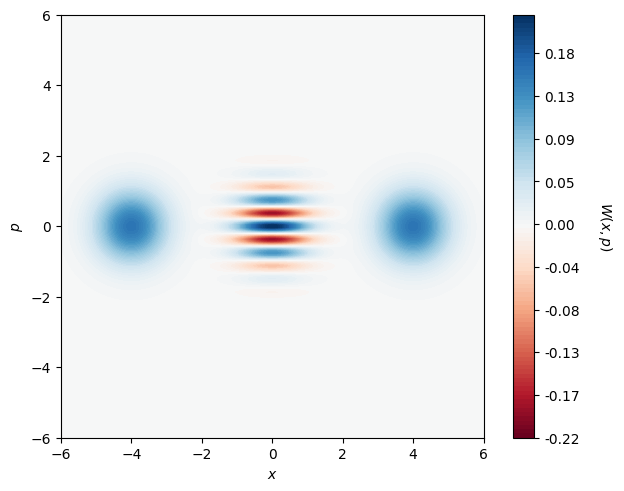

Circuit depth: 8
Number of gates: 8


In [10]:
# Cat state parameters
cutoff = 64
alpha = 4  # Coherent state amplitude

# Create registers and circuit
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(1)
circuit = c2qa.CVCircuit(qmr, qbr)

# Build cat state circuit
circuit = cat_state_circuit(cutoff, circuit, qbr, qmr, alpha=alpha)

# Simulate and visualize
state, _, _ = c2qa.util.simulate(circuit)
fig = c2qa.wigner.plot_wigner(circuit, state)

print(f"Circuit depth: {circuit.depth()}")
print(f"Number of gates: {len(circuit.data)}")

### 2.2 GKP State

The Gottesman-Kitaev-Preskill (GKP) state is a grid state used for quantum error correction.

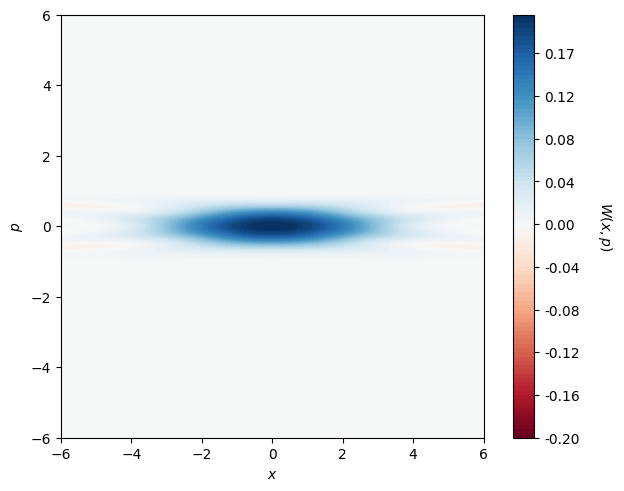

Circuit depth: 64
Number of gates: 65


In [11]:
# GKP state parameters
cutoff = 128
N_rounds = 9  # Number of preparation rounds
r = 1.202     # Squeezing parameter

# Create registers and circuit
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=7, name='qumode')
qbr = QuantumRegister(1)
circuit = c2qa.CVCircuit(qmr, qbr)

# Build GKP state circuit
circuit = gkp_state_circuit(cutoff, circuit, qbr, qmr, N_rounds=N_rounds, r=r)

# Simulate and visualize
state, _, _ = c2qa.util.simulate(circuit)
fig = c2qa.wigner.plot_wigner(circuit, state)

print(f"Circuit depth: {circuit.depth()}")
print(f"Number of gates: {len(circuit.data)}")

<a id='state-transfer'></a>
## 3. State Transfer

### 3.1 CV to DV State Transfer

Transfer quantum information from a continuous-variable mode to discrete-variable qubits using the non-abelian state transfer protocol.

#### 3.1.1 Transfer Fock State 2 to 4 qubits

In [ ]:
# State transfer parameters
cutoff = 64
n_qubits = 4

# Create registers
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(n_qubits)
cr = ClassicalRegister(n_qubits)
circuit = c2qa.CVCircuit(qmr, qbr, cr)

# Build state transfer circuit
circuit.cv_initialize(2, qmr[0])  # Initialize CV mode to |2>
circuit = state_transfer_CVtoDV(cutoff, circuit, qmr, qbr, cr, n_qubits)

# Simulate
state, dv_dist, _ = c2qa.util.simulate(circuit, shots=4096)

# Plot measurement results
plot_histogram(dv_dist.get_counts())
# plt.title('CV to DV State Transfer Results')
# plt.show()

TranspilerError: 'HighLevelSynthesis is unable to synthesize "V1"'

: 

#### 3.1.2 Tranfer Fock State 1 to 4 qubits

In [ ]:
# State transfer parameters
cutoff = 64
n_qubits = 4

# Create registers
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(n_qubits)
cr = ClassicalRegister(n_qubits)
circuit = c2qa.CVCircuit(qmr, qbr, cr)

# Build state transfer circuit
circuit.cv_initialize(1, qmr[0])  # Initialize CV mode to |1>
circuit = state_transfer_CVtoDV(cutoff, circuit, qmr, qbr, cr, n_qubits)

# Simulate
state, dv_dist, _ = c2qa.util.simulate(circuit,shots=4096)

# Plot measurement results
plot_histogram(dv_dist.get_counts())
# plt.title('CV to DV State Transfer Results')
# plt.show()

#### 3.1.3 Transfer Cat State to 4 qubits

In [ ]:
cutoff = 64
alpha = 2  # Coherent state amplitude

# Create registers and circuit
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(4)
cr = ClassicalRegister(4)
circuit = c2qa.CVCircuit(qmr, qbr, cr)

# Build cat state circuit
circuit = cat_state_circuit(cutoff, circuit, qbr, qmr, alpha=alpha)
circuit = state_transfer_CVtoDV(cutoff, circuit, qmr, qbr, cr, 4) # Transfer CAT state to DV

# Simulate
state, dv_dist, _ = c2qa.util.simulate(circuit,shots=4096)

# Plot measurement results
plot_histogram(dv_dist.get_counts())

### 3.2 DV to CV State Transfer

In [ ]:
## Transfer |+++> state to CV mode

cutoff = 128
n_qubits = 3

# Create registers
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=7, name='qumode')
qbr = QuantumRegister(n_qubits)
cr = ClassicalRegister(n_qubits)
circuit = c2qa.CVCircuit(qmr, qbr, cr)

# Build state transfer circuit
for i in range(n_qubits):
    circuit.h(qbr[i])  # Initialize qubits to |+>
circuit.cv_sq(1.0, qmr[0])  # Apply squeezing to CV mode
circuit = state_transfer_DVtoCV(cutoff, circuit, qmr, qbr, cr, n_qubits, lmbda=1.41)

# Simulate
state, dv_dist, _ = c2qa.util.simulate(circuit,shots=1024)
fig = c2qa.wigner.plot_wigner(circuit, state)

<a id='algorithms'></a>
## 4. Quantum Algorithms

### 4.1 Quantum Fourier Transform (QFT)

Hybrid CV-DV implementation of QFT using state transfer protocols.

In [ ]:
# QFT parameters
cutoff = 32
delta = 1.1
n_qubits = 2
n_ancilla = 1
n_append = 2

# Build QFT circuit
circuit = qft_circuit(cutoff, delta, n_qubits, n_ancilla, n_append)

# Simulate
state, dv_dist, _ = c2qa.util.simulate(circuit)

# Show circuit metrics
metrics = collect_cvcircuit_metrics(circuit, cutoff)
print("\nCircuit Metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value}")

In [ ]:
# Plot results
plot_histogram(dv_dist.get_counts())

### 4.2 Variational Quantum Eigensolver (VQE)

Solve the binary knapsack problem using VQE with ECD (Echoed Conditional Displacement) ansatz.

In [ ]:
# Knapsack problem definition
values = [1, 4, 5, 10]
weights = [2.5, 1, 2, 3]
max_weight = 7
l_val = 3  # Penalty parameter

# VQE parameters
nfocks = [8, 8]  # Fock cutoffs for each mode
ndepth = 5       # Circuit depth

# Construct Hamiltonian
bkp_fun, bkp_list = bosonic_vqe.binary_knapsack_ham(l_val, values, weights, max_weight)
bkp_list = bosonic_vqe.binary_to_pauli_list(bkp_fun, bkp_list)
H = Qobj(bosonic_vqe.qubit_op_to_ham(bkp_list).full())

print("Running VQE optimization...")
print(f"  Fock cutoffs: {nfocks}")
print(f"  Circuit depth: {ndepth}")
print(f"  Items: values={values}, weights={weights}")
print(f"  Max weight: {max_weight}")

# Run VQE (reduce iterations for demo)
energy, Xvec, results = binary_knapsack_vqe(
    H, ndepth, nfocks,
    maxiter=60,
    method='BFGS',
    verb=1,
    threshold=1e-6
)

print(f"\nFinal energy: {energy:.6f}")

In [ ]:
# Analyze VQE results
P = bosonic_vqe.num_prob_all(Xvec, ndepth, nfocks)

# Plot probability distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(P.flatten())), P.flatten())
ax.set_xlabel('State Index')
ax.set_ylabel('Probability')
ax.set_title('VQE Solution Probability Distribution')
plt.tight_layout()
plt.show()

# Build the optimized VQE circuit
vqe_circuit = binary_knapsack_vqe_circuit(H, ndepth, nfocks, Xvec)
print(f"VQE circuit depth: {vqe_circuit.depth()}")

### 4.3 CV-QAOA

Continuous-variable Quantum Approximate Optimization Algorithm for finding optimal positions.

In [ ]:
# CV-QAOA parameters
cutoff = 32
s = 1.0    # Squeezing parameter
a = 3.0    # Target position
p = 2      # Number of QAOA layers
n = 2      # Cost function power

print(f"Running CV-QAOA to find x = {a}...")
print(f"  Cutoff: {cutoff}")
print(f"  Layers: {p}")

# Run optimization
result = cv_qaoa(cutoff, s, a, p, n, maxiter=50)

print(f"\nOptimization result:")
print(f"  Success: {result.success}")
print(f"  Final cost: {result.fun:.6f}")
print(f"  Optimal parameters: {result.x}")

In [ ]:
# Build and analyze QAOA circuit
qaoa_circuit = cv_qaoa_circuit(result.x, cutoff, s, a, p, n)

# Simulate final state
state, _, _ = c2qa.util.simulate(qaoa_circuit)

# Visualize Wigner function
fig = c2qa.wigner.plot_wigner(qaoa_circuit, state)
plt.title(f'CV-QAOA Final State (target x = {a})')
plt.show()

<a id='simulation'></a>
## 5. Quantum Simulation

### 5.1 Jaynes-Cummings-Hubbard (JCH) Simulation

Simulate coupled cavity-qubit systems with photon hopping dynamics.

In [ ]:
# JCH parameters
cutoff = 4
Nsites = 3  # Number of sites

# Physical parameters
J = 1.0              # Hopping strength
omega_r = 2*np.pi*2  # Resonator frequency
omega_q = 2*np.pi*2  # Qubit frequency
g = 2*np.pi*0.5      # Coupling strength
tau = 0.1            # Time step

# Create time evolution gate
U1 = JCH_simulation_circuit(
    Nsites, Nqubits=Nsites, cutoff=cutoff,
    J=J, omega_r=omega_r, omega_q=omega_q,
    g=g, tau=tau
)

print(f"JCH simulation setup:")
print(f"  Sites: {Nsites}")
print(f"  Cutoff: {cutoff}")
print(f"  Time step: {tau}")

In [ ]:
# Initialize circuit with photons in first mode
qmr = c2qa.QumodeRegister(Nsites, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))
qbr = QuantumRegister(Nsites)
circuit = c2qa.CVCircuit(qmr, qbr)
circuit.cv_initialize(2, qmr[0])  # Initialize with 2 photons in first mode

# Time evolution
n_steps = 50
tarray = np.arange(0, n_steps * tau, tau)
occupancy_list = np.zeros((len(tarray), Nsites))

print(f"Running JCH simulation for {n_steps} time steps...")
for i, t in enumerate(tarray):
    if (i + 1) % 10 == 0:
        print(f"  Step {i+1}/{len(tarray)}")
    circuit.append(U1, qmr[:] + qbr[:])
    state, result, _ = c2qa.util.simulate(circuit)
    occupancy, _ = c2qa.util.stateread(state, Nsites, Nsites, cutoff, verbose=False, little_endian=False)
    occupancy_list[i, :] = np.array(occupancy[0])

print("Simulation complete!")

In [ ]:
# Plot occupation dynamics
plt.figure(figsize=(10, 5))

for i in range(Nsites):
    plt.plot(tarray, occupancy_list[:, i], label=f'Qumode {i}', marker='o', markersize=3)

plt.title('JCH Simulation: Photon Occupation Dynamics', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Occupation Number', fontsize=14)
plt.ylim(0, 2.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='shors'></a>
## 6. Shor's Algorithm

Hybrid CV-DV implementation of Shor's factoring algorithm using GKP states.

In [ ]:
# Build Shor's circuit
N = 15       # Number to factor
m = 2
R = 15
a = 2        # Base for modular exponentiation
delta = 0.222
cutoff = 64

print(f"Building Shor's circuit for N = {N}...")
circuit = shors_circuit(N, m, R, a, delta, cutoff)

# Get circuit metrics
metrics = collect_cvcircuit_metrics(circuit, cutoff)
print("\nCircuit metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value}")

In [ ]:
# Run Shor's algorithm with success probability estimation
# Note: This can take a while for larger numbers

print(f"Estimating success probability for factoring N = {N}...")
print("(This may take a few minutes)\n")

success_rate, factors, total_successes, total_shots = estimate_success_probability(
    N=N,
    m=2,
    R=15,
    delta=1.202,
    cutoff=64,
    trials=3,    # Reduced for demo
    shots=256    # Reduced for demo
)

print(f"\nResults for N = {N}:")
print(f"  Success rate: {success_rate:.4f}")
print(f"  Factors found: {factors}")
print(f"  Total successes: {total_successes}/{total_shots}")

<a id='metrics'></a>
## 7. Circuit Metrics & Characterization

Collect and analyze metrics for circuit comparison.

In [ ]:
# Collect metrics for various circuits
all_metrics = {}

# Cat state
cutoff = 64
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(1)
cat_circuit = c2qa.CVCircuit(qmr, qbr)
cat_circuit = cat_state_circuit(cutoff, cat_circuit, qbr, qmr, alpha=4)
all_metrics['Cat State'] = collect_cvcircuit_metrics(cat_circuit, cutoff)

# GKP state
cutoff = 64
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(1)
gkp_circuit = c2qa.CVCircuit(qmr, qbr)
gkp_circuit = gkp_state_circuit(cutoff, gkp_circuit, qbr, qmr)
all_metrics['GKP State'] = collect_cvcircuit_metrics(gkp_circuit, cutoff)

# State transfer
cutoff = 64
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6, name='qumode')
qbr = QuantumRegister(4)
cr = ClassicalRegister(4)
st_circuit = c2qa.CVCircuit(qmr, qbr, cr)
st_circuit = state_transfer_CVtoDV(cutoff, st_circuit, qmr, qbr, cr, 4)
all_metrics['State Transfer'] = collect_cvcircuit_metrics(st_circuit, cutoff)

# QFT
qft_circ = qft_circuit(16, 1.1, 2, 1, 2)
all_metrics['QFT'] = collect_cvcircuit_metrics(qft_circ, 16)

print("Circuit metrics summary:")
print("=" * 80)

In [ ]:
import pandas as pd

# Create DataFrame for display
df = pd.DataFrame(all_metrics).T
df = df.round(2)
print(df.to_string())

In [ ]:
# Visualize metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of gate counts
circuits = list(all_metrics.keys())
x = np.arange(len(circuits))
width = 0.25

ax1 = axes[0]
ax1.bar(x - width, [all_metrics[c]['Qubit Gates'] for c in circuits], width, label='Qubit Gates')
ax1.bar(x, [all_metrics[c]['Qumode Gates'] for c in circuits], width, label='Qumode Gates')
ax1.bar(x + width, [all_metrics[c]['Hybrid Gates'] for c in circuits], width, label='Hybrid Gates')
ax1.set_xlabel('Circuit')
ax1.set_ylabel('Gate Count')
ax1.set_title('Gate Count Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(circuits, rotation=45, ha='right')
ax1.legend()

# Bar chart of circuit depth
ax2 = axes[1]
depths = [all_metrics[c]['Circuit Depth'] for c in circuits]
bars = ax2.bar(circuits, depths, color='steelblue')
ax2.set_xlabel('Circuit')
ax2.set_ylabel('Depth')
ax2.set_title('Circuit Depth Comparison')
ax2.set_xticklabels(circuits, rotation=45, ha='right')

# Add value labels on bars
for bar, depth in zip(bars, depths):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{depth}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the key features of HyQBench:

1. **State Preparation**: Cat and GKP state generation
2. **State Transfer**: CV to DV quantum state transfer protocols
3. **Quantum Algorithms**: QFT, VQE, and QAOA implementations
4. **Quantum Simulation**: JCH model dynamics
5. **Cryptographic Applications**: Shor's factoring algorithm
6. **Metrics**: Circuit characterization and comparison

For more details, see the module documentation in `custom_gates/` and `benchmarks/`.